## Phần 1: Tiền xử lý Dữ liệu (Data Preprocessing)
Trong phần này, chúng ta sẽ minh họa trực quan quá trình một câu văn thô được xử lý thông qua 파ipeline: 
1. Cắt từ (Tokenization)
2. Chia 5 phân đoạn (Segmentation) theo vị trí của 2 thực thể thuốc.
3. Xây dựng đồ thị ngữ pháp (Dependency Graph).

In [30]:
import spacy
import numpy as np

# Import các module đã bóc tách từ thư mục preprocessing
from preprocessing.parser import align_tokens_to_chars
from preprocessing.segmenter import get_positions, get_segments
from preprocessing.graph_builder import build_adjacency_matrix

# Load mô hình ngôn ngữ
nlp = spacy.load("en_core_web_sm")
print("Đã nạp thành công các công cụ tiền xử lý!")

Đã nạp thành công các công cụ tiền xử lý!


## Chia phân đoạn câu

In [31]:
# Giả lập một câu chứa tương tác thuốc
text = "Aspirin can increase the risk of bleeding when taken with Warfarin."
# Thực thể 1: Aspirin (ký tự 0-7)
# Thực thể 2: Warfarin (ký tự 58-66)

doc = nlp(text)
tokens = [token.text for token in doc]
seq_len = len(tokens)

# Map thủ công index cho minh họa (Aspirin ở vị trí 0, Warfarin ở vị trí 10)
h_start, h_end = 0, 0 
t_start, t_end = 10, 10 

# Gọi hàm chia 5 phân đoạn
segments = get_segments(seq_len, h_start, h_end, t_start, t_end)

print(f"Câu gốc: {text}\n")
print(f"{'TOKEN':<12} | {'SEGMENT ID':<10} | {'Ý NGHĨA'}")
print("-" * 45)

meanings = {1: "Left", 2: "Entity 1", 3: "Middle", 4: "Entity 2", 5: "Right"}
for token, seg in zip(tokens, segments):
    print(f"{token:<12} | {seg:<10} | {meanings[seg]}")

Câu gốc: Aspirin can increase the risk of bleeding when taken with Warfarin.

TOKEN        | SEGMENT ID | Ý NGHĨA
---------------------------------------------
Aspirin      | 2          | Entity 1
can          | 3          | Middle
increase     | 3          | Middle
the          | 3          | Middle
risk         | 3          | Middle
of           | 3          | Middle
bleeding     | 3          | Middle
when         | 3          | Middle
taken        | 3          | Middle
with         | 3          | Middle
Warfarin     | 4          | Entity 2
.            | 5          | Right


## Ma trận kề

In [32]:
# Gọi hàm xây dựng ma trận đồ thị
adj_matrix = build_adjacency_matrix(doc, seq_len)

print(f"Kích thước ma trận: {adj_matrix.shape} (Tương ứng {seq_len} tokens)\n")
print("--- MA TRẬN KỀ (ADJACENCY MATRIX) ---")
print(adj_matrix)

Kích thước ma trận: (12, 12) (Tương ứng 12 tokens)

--- MA TRẬN KỀ (ADJACENCY MATRIX) ---
[[1 0 1 0 0 0 0 0 0 0 0 0]
 [0 1 1 0 0 0 0 0 0 0 0 0]
 [1 1 1 0 1 0 0 0 0 0 0 1]
 [0 0 0 1 1 0 0 0 0 0 0 0]
 [0 0 1 1 1 1 0 0 0 0 0 0]
 [0 0 0 0 1 1 1 0 0 0 0 0]
 [0 0 0 0 0 1 1 0 1 0 0 0]
 [0 0 0 0 0 0 0 1 1 0 0 0]
 [0 0 0 0 0 0 1 1 1 1 0 0]
 [0 0 0 0 0 0 0 0 1 1 1 0]
 [0 0 0 0 0 0 0 0 0 1 1 0]
 [0 0 1 0 0 0 0 0 0 0 0 1]]


## Phần 2: Kiến trúc Mạng Nơ-ron Seg-GCRNs
Khởi tạo cấu trúc mô hình từ thư mục `models/`. Mô hình bao gồm:
* Lớp Embedding (Word + Position)
* Lớp GCN (Hấp thụ ngữ pháp đồ thị)
* Lớp BiLSTM (Học ngữ cảnh tuần tự)
* Lớp Segmented Max-Pooling (Trích xuất đặc trưng 5 đoạn)
* Lớp Linear Classifier (Phân loại)

## Import Model

In [33]:
import torch
from models.seg_gcrn import SegGCRN

print("Đã import cấu trúc SegGCRN thành công!")

Đã import cấu trúc SegGCRN thành công!


## Khởi tạo và In kiến trúc

In [34]:
# Khởi tạo một mô hình giả định với kích thước từ vựng là 5000
dummy_vocab_size = 5000
model = SegGCRN(
    vocab_size=dummy_vocab_size,
    word_emb_dim=100,
    pos_emb_dim=25,
    max_pos=250,
    gcn_hidden=150,
    lstm_hidden=150,
    num_classes=2
)

# In toàn bộ kiến trúc để kiểm tra số lượng tham số các layer
print(model)

SegGCRN(
  (word_emb): Embedding(5000, 100, padding_idx=0)
  (pos1_emb): Embedding(250, 25, padding_idx=0)
  (pos2_emb): Embedding(250, 25, padding_idx=0)
  (gcn1): GCNLayer(
    (linear): Linear(in_features=150, out_features=150, bias=True)
  )
  (gcn2): GCNLayer(
    (linear): Linear(in_features=150, out_features=150, bias=True)
  )
  (bilstm): BiLSTMLayer(
    (lstm): LSTM(150, 150, batch_first=True, bidirectional=True)
  )
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=1500, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)


## Phần 3: Huấn luyện và Đánh giá (Train & Evaluate)
Phần này thực thi quá trình đẩy dữ liệu qua mạng nơ-ron, tính toán hàm CrossEntropyLoss, lan truyền ngược (Backpropagation) và cập nhật trọng số bằng thuật toán Adam.

## Thiết lập Dữ liệu & Thiết bị

In [40]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

from dataset.data_loader import get_dataloader

# ==========================================
# 1. THIẾT LẬP ĐƯỜNG DẪN 3 TẬP DỮ LIỆU
# ==========================================
project_root = os.getcwd()

# Dùng 2 file mới cắt thay cho file train_processed gốc
train_80_file = os.path.join(project_root, "data", "processed", "train_80_split.json")
val_20_file = os.path.join(project_root, "data", "processed", "val_20_split.json")

# File Test giữ nguyên
test_file = os.path.join(project_root, "data", "processed", "test_processed.json")
vocab_file = os.path.join(project_root, "data", "processed", "vocab.json")

# ==========================================
# 2. LẤY KÍCH THƯỚC TỪ ĐIỂN
# ==========================================
with open(vocab_file, 'r', encoding='utf-8') as f:
    vocab_data = json.load(f)
    vocab_size = len(vocab_data)

print(f"Kích thước từ vựng (Vocab Size): {vocab_size}")

# ==========================================
# 3. KHỞI TẠO 3 DATALOADER CHUẨN QUỐC TẾ
# ==========================================
BATCH_SIZE = 32

# Train thì xáo trộn (shuffle=True) để máy học không bị rập khuôn
train_loader = get_dataloader(train_80_file, vocab_file, batch_size=BATCH_SIZE, shuffle=True)

# Val và Test thì KHÔNG xáo trộn (shuffle=False) để đánh giá cho chuẩn
val_loader = get_dataloader(val_20_file, vocab_file, batch_size=BATCH_SIZE, shuffle=False)
test_loader = get_dataloader(test_file, vocab_file, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Thiết bị tính toán: {device}")

Kích thước từ vựng (Vocab Size): 5357
Thiết bị tính toán: cpu


## Vòng lặp Huấn luyện chính

In [44]:
# Khởi tạo mô hình thật 
real_model = SegGCRN(
    vocab_size=vocab_size,
    word_emb_dim=100,
    pos_emb_dim=25,
    max_pos=250, 
    gcn_hidden=150,
    lstm_hidden=150,
    num_classes=2
).to(device)

# 1. TRỌNG SỐ 
weights = torch.tensor([1.0, 6.3]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights)

# 2. TỐI ƯU HÓA
optimizer = optim.Adam(real_model.parameters(), lr=0.0005, weight_decay=1e-5)

# 3. SỐ VÒNG LẶP VÀ ĐƯỜNG DẪN LƯU
EPOCHS = 30
best_val_f1 = 0.0

model_save_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
os.makedirs(os.path.dirname(model_save_path), exist_ok=True)

print(f"========== BẮT ĐẦU HUẤN LUYỆN ({EPOCHS} VÒNG) ==========")
for epoch in range(1, EPOCHS + 1):
    real_model.train()
    total_loss = 0
    
    # --- HỌC TRÊN TẬP TRAIN ---
    for batch in train_loader:
        token_ids = batch['token_ids'].to(device)
        pos1 = batch['pos1'].to(device)
        pos2 = batch['pos2'].to(device)
        segments = batch['segments'].to(device)
        adj_matrix = batch['adj_matrix'].to(device)
        masks = batch['masks'].to(device)
        labels = batch['labels'].to(device)
        
        optimizer.zero_grad()
        logits = real_model(token_ids, pos1, pos2, adj_matrix, segments, masks)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    avg_train_loss = total_loss / len(train_loader)
    
    # --- THI THỬ TRÊN TẬP VALIDATION ---
    real_model.eval()
    val_preds, val_labels = [], []
    with torch.no_grad():
        for batch in val_loader: 
            token_ids = batch['token_ids'].to(device)
            pos1 = batch['pos1'].to(device)
            pos2 = batch['pos2'].to(device)
            segments = batch['segments'].to(device)
            adj_matrix = batch['adj_matrix'].to(device)
            masks = batch['masks'].to(device)
            labels = batch['labels'].to(device)
            
            logits = real_model(token_ids, pos1, pos2, adj_matrix, segments, masks)
            preds = torch.argmax(logits, dim=1)
            
            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(labels.cpu().numpy())
            
    # Tính các chỉ số Validation
    val_acc = accuracy_score(val_labels, val_preds)
    val_prec = precision_score(val_labels, val_preds, zero_division=0)
    val_rec = recall_score(val_labels, val_preds, zero_division=0)
    val_f1 = f1_score(val_labels, val_preds, zero_division=0)
    
    print(f"[Epoch {epoch}/{EPOCHS}] Train Loss: {avg_train_loss:.4f} | Val Acc: {val_acc:.4f} | Val Prec: {val_prec:.4f} | Val Rec: {val_rec:.4f} | Val F1: {val_f1:.4f}")
    
    # Lưu mô hình
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(real_model.state_dict(), model_save_path)
        print(f"  [!] -> Kỷ lục Val mới! Đã lưu file best_seg_gcrn.pth (Val F1: {best_val_f1:.4f})")
print("========== HOÀN TẤT HUẤN LUYỆN ==========")

========== BẮT ĐẦU HUẤN LUYỆN (30 VÒNG) ==========
[Epoch 1/30] Train Loss: 0.4753 | Val Acc: 0.8367 | Val Prec: 0.3631 | Val Rec: 0.7901 | Val F1: 0.4975
  [!] -> Kỷ lục Val mới! Đã lưu file best_seg_gcrn.pth (Val F1: 0.4975)
[Epoch 2/30] Train Loss: 0.3433 | Val Acc: 0.8475 | Val Prec: 0.3893 | Val Rec: 0.8634 | Val F1: 0.5366
  [!] -> Kỷ lục Val mới! Đã lưu file best_seg_gcrn.pth (Val F1: 0.5366)
[Epoch 3/30] Train Loss: 0.2703 | Val Acc: 0.9034 | Val Prec: 0.5199 | Val Rec: 0.7228 | Val F1: 0.6048
  [!] -> Kỷ lục Val mới! Đã lưu file best_seg_gcrn.pth (Val F1: 0.6048)
[Epoch 4/30] Train Loss: 0.2183 | Val Acc: 0.8768 | Val Prec: 0.4447 | Val Rec: 0.8198 | Val F1: 0.5766
[Epoch 5/30] Train Loss: 0.1717 | Val Acc: 0.9062 | Val Prec: 0.5288 | Val Rec: 0.7644 | Val F1: 0.6251
  [!] -> Kỷ lục Val mới! Đã lưu file best_seg_gcrn.pth (Val F1: 0.6251)
[Epoch 6/30] Train Loss: 0.1396 | Val Acc: 0.9149 | Val Prec: 0.5734 | Val Rec: 0.6574 | Val F1: 0.6125
[Epoch 7/30] Train Loss: 0.1262 | Val

## Đánh giá model tốt nhất đã lưu trên tập test

In [46]:
import os
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

print("\n" + "="*60)
print("  ĐÁNH GIÁ CHUNG CUỘC TRÊN TẬP TEST (UNSEEN DATA)")
print("="*60)

# Khởi tạo một vỏ não trống
test_model = SegGCRN(
    vocab_size=vocab_size,
    word_emb_dim=100,
    pos_emb_dim=25,
    max_pos=250, 
    gcn_hidden=150,
    lstm_hidden=150,
    num_classes=2
).to(device)

# Load bộ não xuất sắc nhất từ ổ cứng vào vỏ não
model_save_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
test_model.load_state_dict(torch.load(model_save_path))
test_model.eval()

test_preds, test_labels = [], []

# Bắt đầu thi thật
with torch.no_grad():
    for batch in test_loader: 
        token_ids = batch['token_ids'].to(device)
        pos1 = batch['pos1'].to(device)
        pos2 = batch['pos2'].to(device)
        segments = batch['segments'].to(device)
        adj_matrix = batch['adj_matrix'].to(device)
        masks = batch['masks'].to(device)
        labels = batch['labels'].to(device)
        
        logits = test_model(token_ids, pos1, pos2, adj_matrix, segments, masks)
        preds = torch.argmax(logits, dim=1)
        
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(labels.cpu().numpy())

# Tính toán điểm
test_acc = accuracy_score(test_labels, test_preds)
test_prec = precision_score(test_labels, test_preds, zero_division=0)
test_rec = recall_score(test_labels, test_preds, zero_division=0)
test_f1 = f1_score(test_labels, test_preds, zero_division=0)

print(f" FINAL TEST ACCURACY  : {test_acc*100:.2f}%")
print(f" FINAL TEST PRECISION : {test_prec*100:.2f}%")
print(f" FINAL TEST RECALL    : {test_rec*100:.2f}%")
print(f" FINAL TEST F1-SCORE  : {test_f1*100:.2f}%")
print("="*60)


  ĐÁNH GIÁ CHUNG CUỘC TRÊN TẬP TEST (UNSEEN DATA)
 FINAL TEST ACCURACY  : 91.35%
 FINAL TEST PRECISION : 55.24%
 FINAL TEST RECALL    : 80.98%
 FINAL TEST F1-SCORE  : 65.68%


## Báo cáo Kết quả Cuối cùng

In [48]:
import os
import torch
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# ==========================================
# 1. HÀM ĐÁNH GIÁ (Rút gọn code cho chuyên nghiệp)
# ==========================================
def evaluate_model(model, dataloader, device):
    model.eval()
    all_preds, all_labels = [], []
    
    with torch.no_grad():
        for batch in dataloader:
            token_ids = batch['token_ids'].to(device)
            pos1 = batch['pos1'].to(device)
            pos2 = batch['pos2'].to(device)
            segments = batch['segments'].to(device)
            adj_matrix = batch['adj_matrix'].to(device)
            masks = batch['masks'].to(device)
            labels = batch['labels'].to(device)
            
            logits = model(token_ids, pos1, pos2, adj_matrix, segments, masks)
            preds = torch.argmax(logits, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return acc, prec, rec, f1

# ==========================================
# 2. LOAD MÔ HÌNH XUẤT SẮC NHẤT TỪ Ổ CỨNG
# ==========================================
# Khởi tạo vỏ não trống
test_model = SegGCRN(
    vocab_size=vocab_size,
    word_emb_dim=100,
    pos_emb_dim=25,
    max_pos=250, 
    gcn_hidden=150,
    lstm_hidden=150,
    num_classes=2
).to(device)

# Nạp trí nhớ (trọng số) vào
model_save_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
test_model.load_state_dict(torch.load(model_save_path))

# ==========================================
# 3. CHẤM ĐIỂM & IN BẢNG BÁO CÁO
# ==========================================
# Gọi hàm để lấy điểm của cả 2 tập
val_acc, val_prec, val_rec, val_f1 = evaluate_model(test_model, val_loader, device)
test_acc, test_prec, test_rec, test_f1 = evaluate_model(test_model, test_loader, device)

# Vẽ bảng ASCII cực đẹp
print("\n" + "="*65)
print("  BÁO CÁO HIỆU SUẤT TỔNG THỂ (BEST CHECKPOINT SEG-GCRN)")
print("="*65)
print(f"| {'Chỉ số (Metrics)':<20} | {'Validation Set':<17} | {'Test Set (Unseen)':<17} |")
print("-" * 65)
print(f"| {'Accuracy':<20} | {val_acc*100:>16.2f}% | {test_acc*100:>16.2f}% |")
print(f"| {'Precision':<20} | {val_prec*100:>16.2f}% | {test_prec*100:>16.2f}% |")
print(f"| {'Recall':<20} | {val_rec*100:>16.2f}% | {test_rec*100:>16.2f}% |")
print(f"| {'F1-Score':<20} | {val_f1*100:>16.2f}% | {test_f1*100:>16.2f}% |")
print("="*65 + "\n")
print("Model học tốt không học vẹt sự chênh lệch các chỉ số không đáng kể")


  BÁO CÁO HIỆU SUẤT TỔNG THỂ (BEST CHECKPOINT SEG-GCRN)
| Chỉ số (Metrics)     | Validation Set    | Test Set (Unseen) |
-----------------------------------------------------------------
| Accuracy             |            91.61% |            91.35% |
| Precision            |            56.72% |            55.24% |
| Recall               |            76.04% |            80.98% |
| F1-Score             |            64.97% |            65.68% |

Model học tốt không học vẹt sự chênh lệch các chỉ số không đáng kể


## Ma trận nhầm lẫn


In [49]:
import json
import os

project_root = os.getcwd() 
test_file = os.path.join(project_root, "data", "processed", "test_processed.json")

with open(test_file, 'r', encoding='utf-8') as f:
    data = json.load(f)
    print(f"Số lượng cặp thuốc thực tế trong file JSON là: {len(data)}")

Số lượng cặp thuốc thực tế trong file JSON là: 6171



  ĐÁNH GIÁ CHUNG CUỘC TRÊN TẬP TEST (CÓ MA TRẬN NHẦM LẪN)
Đang chấm điểm trên toàn bộ tập Test...

  BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)
              precision    recall  f1-score   support

   FALSE (0)       0.98      0.93      0.95      5540
    TRUE (1)       0.55      0.81      0.66       631

    accuracy                           0.91      6171
   macro avg       0.76      0.87      0.80      6171
weighted avg       0.93      0.91      0.92      6171


[!] Đã lưu ảnh Ma trận nhầm lẫn nét căng tại: d:\nlp(yte)\graph-embedding-relation-extraction\confusion_matrix.png


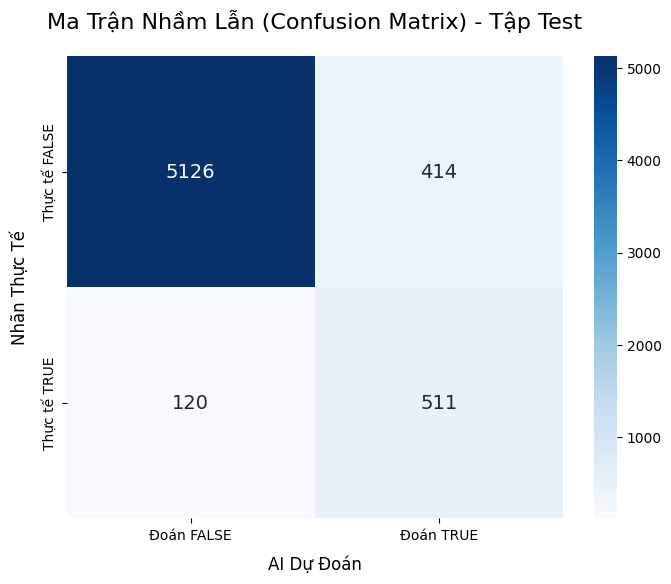

In [53]:
import os
import torch
import json
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

print("\n" + "="*60)
print("  ĐÁNH GIÁ CHUNG CUỘC TRÊN TẬP TEST (CÓ MA TRẬN NHẦM LẪN)")
print("="*60)

# ==========================================
# 1. KHỞI TẠO MÔ HÌNH CHUẨN XÁC
# ==========================================
test_model = SegGCRN(
    vocab_size=vocab_size,
    word_emb_dim=100,
    pos_emb_dim=25,
    max_pos=250, 
    gcn_hidden=150,
    lstm_hidden=150,
    num_classes=2
).to(device)

model_save_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
test_model.load_state_dict(torch.load(model_save_path, map_location=device))
test_model.eval()

all_preds, all_labels = [], []

# ==========================================
# 2. CHẠY TOÀN BỘ TẬP TEST
# ==========================================
print("Đang chấm điểm trên toàn bộ tập Test...")
with torch.no_grad():
    for batch in test_loader:
        token_ids = batch['token_ids'].to(device)
        pos1 = batch['pos1'].to(device)
        pos2 = batch['pos2'].to(device)
        segments = batch['segments'].to(device)
        adj_matrix = batch['adj_matrix'].to(device)
        masks = batch['masks'].to(device)
        labels = batch['labels'].to(device)
        
        logits = test_model(token_ids, pos1, pos2, adj_matrix, segments, masks)
        preds = torch.argmax(logits, dim=1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# ==========================================
# 3. IN BÁO CÁO PHÂN LOẠI (SKLEARN)
# ==========================================
print("\n" + "="*55)
print("  BÁO CÁO PHÂN LOẠI (CLASSIFICATION REPORT)")
print("="*55)
print(classification_report(all_labels, all_preds, target_names=["FALSE (0)", "TRUE (1)"], zero_division=0))

# ==========================================
# 4. VẼ MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
# Vẽ heatmap với màu xanh dương nhạt (Blues) cực kỳ chuyên nghiệp
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Đoán FALSE", "Đoán TRUE"], 
            yticklabels=["Thực tế FALSE", "Thực tế TRUE"],
            annot_kws={"size": 14})

plt.title('Ma Trận Nhầm Lẫn (Confusion Matrix) - Tập Test', fontsize=16, pad=20)
plt.xlabel('AI Dự Đoán', fontsize=12, labelpad=10)
plt.ylabel('Nhãn Thực Tế', fontsize=12, labelpad=10)

# Lưu ảnh chất lượng cao (dpi=300) để dán vào Word/PowerPoint không bị vỡ
save_path = os.path.join(project_root, "confusion_matrix.png")
plt.savefig(save_path, dpi=300, bbox_inches='tight')

print(f"\n[!] Đã lưu ảnh Ma trận nhầm lẫn nét căng tại: {save_path}")
plt.show()

In [ ]:
import os
import json
import time
import torch
import spacy
import torch.nn.functional as F

# Import các hàm tiền xử lý
from preprocessing.parser import align_tokens_to_chars
from preprocessing.segmenter import get_positions, get_segments
from preprocessing.graph_builder import build_adjacency_matrix
from models.seg_gcrn import SegGCRN

# THÊM THAM SỐ temperature VÀO HÀM (Mặc định = 2.0)
def predict_ddi(text, drug1, drug2, temperature=2.0):
    print(f"\n[AI ĐANG PHÂN TÍCH (T = {temperature})]...")
    print(f"Câu bệnh án: '{text}'")
    print(f"Thuốc 1: {drug1} | Thuốc 2: {drug2}")
    
    # 1. Tìm vị trí ký tự
    h_start = text.find(drug1)
    t_start = text.find(drug2)
    
    if h_start == -1 or t_start == -1:
        print("[LỖI] Không tìm thấy tên thuốc trong câu!")
        return
        
    h_end = h_start + len(drug1)
    t_end = t_start + len(drug2)

    # 2. Tiền xử lý NLP
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    tokens = [token.text for token in doc]
    seq_len = len(tokens)
    
    h_t_start, h_t_end = align_tokens_to_chars(doc, h_start, h_end, drug1)
    t_t_start, t_t_end = align_tokens_to_chars(doc, t_start, t_end, drug2)
    
    if h_t_start == -1 or t_t_start == -1:
        print("[LỖI] SpaCy không thể cắt từ chuẩn xác. Hãy thử câu khác.")
        return

    # Lấy vị trí thô
    pos1_raw = get_positions(seq_len, h_t_start, h_t_end)
    pos2_raw = get_positions(seq_len, t_t_start, t_t_end)
    segments = get_segments(seq_len, h_t_start, h_t_end, t_t_start, t_t_end)
    adj_matrix = build_adjacency_matrix(doc, seq_len)
    
    # 3. Load Vocab
    project_root = os.getcwd() 
    vocab_file = os.path.join(project_root, "data", "processed", "vocab.json")
    
    with open(vocab_file, 'r', encoding='utf-8') as f:
        vocab = json.load(f)
        
    token_ids = [vocab.get(t.lower(), 1) for t in tokens] 
    
    # 4. Tiền xử lý vị trí 
    POSITION_SHIFT = 120
    pos1_shifted = [p + POSITION_SHIFT for p in pos1_raw]
    pos2_shifted = [p + POSITION_SHIFT for p in pos2_raw]

    token_ids_t = torch.tensor([token_ids], dtype=torch.long)
    segments_t = torch.tensor([segments], dtype=torch.long)
    adj_matrix_t = torch.from_numpy(adj_matrix).float().unsqueeze(0)
    masks_t = torch.ones(1, seq_len, dtype=torch.float)
    
    pos1_t = torch.clamp(torch.tensor([pos1_shifted]), min=1, max=249)
    pos2_t = torch.clamp(torch.tensor([pos2_shifted]), min=1, max=249)
    
    # 5. KHỞI TẠO VÀ LOAD MODEL 
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SegGCRN(
        vocab_size=len(vocab),
        word_emb_dim=100,
        pos_emb_dim=25,
        max_pos=250, 
        gcn_hidden=150,
        lstm_hidden=150,
        num_classes=2
    ).to(device)
    
    model_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 6. DỰ ĐOÁN & ÁP DỤNG TEMPERATURE SCALING
    start_infer = time.time()
    with torch.no_grad():
        logits = model(
            token_ids_t.to(device), pos1_t.to(device), pos2_t.to(device), 
            adj_matrix_t.to(device), segments_t.to(device), masks_t.to(device)
        )
        
        scaled_logits = logits / temperature
        
        probs = F.softmax(scaled_logits, dim=1)[0]
        prediction = torch.argmax(logits, dim=1).item() # Dự đoán cuối cùng (Argmax) giữ nguyên
        
    end_infer = time.time() 
    process_time_ms = (end_infer - start_infer) * 1000
        
    # 7. In kết quả
    print("-" * 55)
    if prediction == 1:
        print(f" KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)")
    else:
        print(f" KẾT LUẬN: KHÔNG CÓ TƯƠNG TÁC (FALSE)")
        
    print(f"   • Độ tự tin AI : {probs[prediction]*100:.1f}%")
    print(f"   • Thời gian xử lý : {process_time_ms:.2f} ms")
    print("-" * 55)

# ================= CHẠY THỬ VỚI CÁC MỨC KHÁC NHAU =================

print("\n>>> KIỂM TRA MỨC ĐỘ HIỆU CHUẨN (CALIBRATION TEST) <<<")

# Test 1: Nhiệt độ bình thường (T = 1.0)
predict_ddi(
    text="Cimetidine inhibits the CYP3A4 metabolism of nifedipine, thereby increasing its plasma concentration and the risk of hypotension.",
    drug1="Cimetidine",
    drug2="nifedipine",
    temperature=1.0
)

# Test 2: Tăng nhiệt độ (T = 2.0) 
predict_ddi(
    text="Cimetidine inhibits the CYP3A4 metabolism of nifedipine, thereby increasing its plasma concentration and the risk of hypotension.",
    drug1="Cimetidine",
    drug2="nifedipine",
    temperature=2.0
)

# Test 3: Tăng nhiệt độ cao (T = 5.0) 
predict_ddi(
    text="Cimetidine inhibits the CYP3A4 metabolism of nifedipine, thereby increasing its plasma concentration and the risk of hypotension.",
    drug1="Cimetidine",
    drug2="nifedipine",
    temperature=5.0
)


>>> KIỂM TRA MỨC ĐỘ HIỆU CHUẨN (CALIBRATION TEST) <<<

[AI ĐANG PHÂN TÍCH (T = 1.0)]...
Câu bệnh án: 'Cimetidine inhibits the CYP3A4 metabolism of nifedipine, thereby increasing its plasma concentration and the risk of hypotension.'
Thuốc 1: Cimetidine | Thuốc 2: nifedipine
-------------------------------------------------------
 KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)
   • Độ tự tin AI : 100.0%
   • Thời gian xử lý : 2.52 ms
-------------------------------------------------------

[AI ĐANG PHÂN TÍCH (T = 2.0)]...
Câu bệnh án: 'Cimetidine inhibits the CYP3A4 metabolism of nifedipine, thereby increasing its plasma concentration and the risk of hypotension.'
Thuốc 1: Cimetidine | Thuốc 2: nifedipine
-------------------------------------------------------
 KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)
   • Độ tự tin AI : 99.9%
   • Thời gian xử lý : 1.00 ms
-------------------------------------------------------

[AI ĐANG PHÂN TÍCH (T = 5.0)]...
Câu bệnh án: 'Cimetidine inhibits the CYP3A4 metabolism 

In [8]:
import os
import json
import time
import torch
import spacy
import torch.nn.functional as F

# Import các hàm tiền xử lý
from preprocessing.parser import align_tokens_to_chars
from preprocessing.segmenter import get_positions, get_segments
from preprocessing.graph_builder import build_adjacency_matrix
from models.seg_gcrn import SegGCRN

# Thêm tham số temperature=4.0 làm mặc định
def predict_ddi(text, drug1, drug2, temperature=4.0):
    print(f"\n[AI ĐANG PHÂN TÍCH (T={temperature})]...")
    print(f"Câu bệnh án: '{text}'")
    print(f"Thuốc 1: {drug1} | Thuốc 2: {drug2}")
    
    # 1. Tìm vị trí ký tự
    h_start = text.find(drug1)
    t_start = text.find(drug2)
    
    if h_start == -1 or t_start == -1:
        print("[LỖI] Không tìm thấy tên thuốc trong câu!")
        return
        
    h_end = h_start + len(drug1)
    t_end = t_start + len(drug2)

    # 2. Tiền xử lý NLP
    nlp = spacy.load("en_core_web_sm")
    doc = nlp(text)
    tokens = [token.text for token in doc]
    seq_len = len(tokens)
    
    h_t_start, h_t_end = align_tokens_to_chars(doc, h_start, h_end, drug1)
    t_t_start, t_t_end = align_tokens_to_chars(doc, t_start, t_end, drug2)
    
    if h_t_start == -1 or t_t_start == -1:
        print("[LỖI] SpaCy không thể cắt từ chuẩn xác. Hãy thử câu khác.")
        return

    # Lấy vị trí thô (có số âm)
    pos1_raw = get_positions(seq_len, h_t_start, h_t_end)
    pos2_raw = get_positions(seq_len, t_t_start, t_t_end)
    segments = get_segments(seq_len, h_t_start, h_t_end, t_t_start, t_t_end)
    adj_matrix = build_adjacency_matrix(doc, seq_len)
    
    # 3. Load Vocab
    project_root = os.getcwd() 
    vocab_file = os.path.join(project_root, "data", "processed", "vocab.json")
    
    with open(vocab_file, 'r', encoding='utf-8') as f:
        vocab = json.load(f)
        
    token_ids = [vocab.get(t.lower(), 1) for t in tokens] 
    
    # 4. Tiền xử lý vị trí (Giả lập quy trình của DataLoader)
    POSITION_SHIFT = 120
    pos1_shifted = [p + POSITION_SHIFT for p in pos1_raw]
    pos2_shifted = [p + POSITION_SHIFT for p in pos2_raw]

    # Ép kiểu Tensor và thêm chiều Batch
    token_ids_t = torch.tensor([token_ids], dtype=torch.long)
    segments_t = torch.tensor([segments], dtype=torch.long)
    adj_matrix_t = torch.from_numpy(adj_matrix).float().unsqueeze(0)
    masks_t = torch.ones(1, seq_len, dtype=torch.float)
    
    # Clamp cứng giống collate_fn
    pos1_t = torch.clamp(torch.tensor([pos1_shifted]), min=1, max=249)
    pos2_t = torch.clamp(torch.tensor([pos2_shifted]), min=1, max=249)
    
    # 5. KHỞI TẠO VÀ LOAD MODEL (ĐÃ SỬA THAM SỐ)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = SegGCRN(
        vocab_size=len(vocab),
        word_emb_dim=100,
        pos_emb_dim=25,
        max_pos=250, 
        gcn_hidden=150,
        lstm_hidden=150,
        num_classes=2
    ).to(device)
    
    model_path = os.path.join(project_root, "models", "best_seg_gcrn.pth")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()
    
    # 6. Dự đoán
    start_infer = time.time()
    with torch.no_grad():
        logits = model(
            token_ids_t.to(device), pos1_t.to(device), pos2_t.to(device), 
            adj_matrix_t.to(device), segments_t.to(device), masks_t.to(device)
        )
        
        # --- ÁP DỤNG TEMPERATURE SCALING TẠI ĐÂY ---
        scaled_logits = logits / temperature
        probs = F.softmax(scaled_logits, dim=1)[0]
        prediction = torch.argmax(logits, dim=1).item() # Vẫn dùng argmax trên logits gốc
        
    end_infer = time.time() 
    process_time_ms = (end_infer - start_infer) * 1000
        
    # 7. In kết quả
    print("-" * 55)
    if prediction == 1:
        print(f" KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)")
    else:
        print(f" KẾT LUẬN: KHÔNG CÓ TƯƠNG TÁC (FALSE)")
        
    print(f"   • Độ tự tin AI : {probs[prediction]*100:.1f}%")
    print(f"   • Thời gian xử lý : {process_time_ms:.2f} ms")
    print("-" * 55)

# ================= KỊCH BẢN DEMO THỰC TẾ =================

predict_ddi(
    text="The doctor prescribed aspirin along with amoxicillin to be taken in the evening..",
    drug1="aspirin",
    drug2="amoxicillin"
)
predict_ddi(
    text="Additionally, anti-malarial drugs, such as chloroquine and mefloquine, may antagonize the activity of carbamazepine",
    drug1="chloroquine",
    drug2="carbamazepine"
)
predict_ddi(
    text="Benzthiazide may interact with alcohol, blood thinners, decongestant drugs (allergy, cold, and sinus medicines), diabetic drugs, lithium, norepinephrine, NSAIDs like Aleve or Ibuprofen, and high blood pressure medications.",
    drug1="Benzthiazide",
    drug2="Ibuprofen"
)
predict_ddi(
    text="The concomitant use of bumetanide with aminoglycoside antibiotics should be avoided, except in life-threatening situations.",
    drug1="bumetanide",
    drug2="aminoglycoside antibiotics"
)
predict_ddi(
    text="The patient was prescribed ibuprofen to relieve headaches and amoxicillin to relieve nausea.",
    drug1="ibuprofen",
    drug2="amoxicillin"
)
predict_ddi(
    text="Population pharmacokinetic analyses showed that MTX and corticosteroid inhibitors did not affect abatacept clearance.",
    drug1="MTX",
    drug2="corticosteroid"
)
predict_ddi(
    text="No clinically significant interaction was observed between aspirin and metformin.",
    drug1="aspirin",
    drug2="metformin"
)
predict_ddi(
    text="aspirin did not affect the pharmacokinetics of metformin in healthy volunteers.",
    drug1="aspirin",
    drug2="metformin"
)
predict_ddi(
    text="Co-administration of warfarin and aspirin significantly increased the risk of bleeding.",
    drug1="warfarin",
    drug2="aspirin"
)
predict_ddi(
    text="ketoconazole increased the plasma concentration of cyclosporine by inhibiting CYP3A4 metabolism.",
    drug1="ketoconazole",
    drug2="cyclosporine"
)
predict_ddi(
    text="Although aspirin and metformin were administered together, no interaction was detected.",
    drug1="aspirin",
    drug2="metformin"
)
predict_ddi(
    text="Current evidence neither confirms nor excludes a clinically meaningful interaction between aspirin and metformin.",
    drug1="aspirin",
    drug2="metformin"
)


[AI ĐANG PHÂN TÍCH (T=4.0)]...
Câu bệnh án: 'The doctor prescribed aspirin along with amoxicillin to be taken in the evening..'
Thuốc 1: aspirin | Thuốc 2: amoxicillin
-------------------------------------------------------
 KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)
   • Độ tự tin AI : 90.6%
   • Thời gian xử lý : 3.50 ms
-------------------------------------------------------

[AI ĐANG PHÂN TÍCH (T=4.0)]...
Câu bệnh án: 'Additionally, anti-malarial drugs, such as chloroquine and mefloquine, may antagonize the activity of carbamazepine'
Thuốc 1: chloroquine | Thuốc 2: carbamazepine
-------------------------------------------------------
 KẾT LUẬN: CÓ TƯƠNG TÁC THUỐC (TRUE)
   • Độ tự tin AI : 77.5%
   • Thời gian xử lý : 1.00 ms
-------------------------------------------------------

[AI ĐANG PHÂN TÍCH (T=4.0)]...
Câu bệnh án: 'Benzthiazide may interact with alcohol, blood thinners, decongestant drugs (allergy, cold, and sinus medicines), diabetic drugs, lithium, norepinephrine, NSAIDs lik